# Carbon and water intensity traces

Build the full carbon and water intensity traces `traces/{DE,FR,PL}.csv` for the environmental-aware scheduling experiments. For each country, take the ENTSO-E actual generation per production type from 2018 through 2025, weight the per-source carbon and water intensity factors by the generation mix at each instant, and write a 15-minute resolution trace in the long format Batsim consumes.

The per-source factors and their provenance are documented in `README.md`: carbon from UNECE 2020 where available, else IPCC 2014, water from Macknick et al. 2012.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from entsoe import EntsoePandasClient
from entsoe.mappings import lookup_area

In [2]:
COUNTRIES = ["DE", "FR", "PL"]
START, END = "2018-01-01", "2026-01-01"  # local time, end exclusive

ZONE_ID = "AS0"  # zone name used inside the traces
STEP_SEC = 900
SAMPLE_WEEK = "2021-06-07"  # Monday of the week shown in the zoomed plots
STORAGE_SOURCES = {"Energy storage", "Hydro Pumped Storage"}

# Per-source intensity factors (UNECE 2020 defaults where available, else
# IPCC 2014). Keys must match source names returned by ENTSO-E. See
# README.md for the provenance of every value.
CARBON_INTENSITY = {  # gCO2-eq/kWh
    "Biomass": 230, "Fossil Gas": 280, "Fossil Hard coal": 630, "Fossil Oil": 280,
    "Fossil Brown coal/Lignite": 1000, "Fossil Coal-derived gas": 630,
    "Hydro Run-of-river and poundage": 81, "Hydro Water Reservoir": 81,
    "Nuclear": 5.1, "Solar": 21, "Waste": 230, "Geothermal": 38,
    "Wind Offshore": 13, "Wind Onshore": 12,
    "Other": 280, "Other renewable": 230,
}
WATER_INTENSITY = {  # L/kWh
    "Biomass": 1.147, "Fossil Gas": 1.086, "Fossil Hard coal": 1.802, "Fossil Oil": 1.086,
    "Fossil Brown coal/Lignite": 1.802, "Fossil Coal-derived gas": 1.802,
    "Hydro Run-of-river and poundage": 17.0, "Hydro Water Reservoir": 17.0,
    "Nuclear": 1.957, "Solar": 0.004, "Waste": 1.147, "Geothermal": 0.95,
    "Wind Offshore": 0, "Wind Onshore": 0,
    "Other": 1.086, "Other renewable": 1.147,
}

## Loading the generation data

ENTSO-E actual generation per production type (nett of consumption), 2018 through 2025 in each country's local time. The raw responses are cached in `raw/<CC>.csv` (Git LFS): with the caches present the notebook runs fully offline. A missing cache is fetched from the ENTSO-E API, which requires the `ENTSOE_API_KEY` environment variable, and saved for the next run. Delete a cache file to force a fresh download.

The cache index mixes CET/CEST offsets, so it is parsed through UTC before converting back to the country timezone.

In [3]:
raw = {}
for cc in COUNTRIES:
    tz = lookup_area(cc).tz
    path = f"raw/{cc}.csv"
    if os.path.exists(path):
        gen = pd.read_csv(path, index_col=0)
        gen.index = pd.to_datetime(gen.index, utc=True).tz_convert(tz)
    else:
        api_key = os.environ.get("ENTSOE_API_KEY")
        assert api_key, "ENTSOE_API_KEY environment variable is not set"
        start, end = pd.Timestamp(START, tz=tz), pd.Timestamp(END, tz=tz)
        print(f"{cc}: fetching generation from {start.date()} to {end.date()}...")
        client = EntsoePandasClient(api_key=api_key)
        gen = client.query_generation(cc, start=start, end=end, nett=True)
        gen.to_csv(path)
    raw[cc] = gen
    print(f"{cc}: {len(gen)} rows at {gen.index[1] - gen.index[0]}, {gen.shape[1]} sources, "
          f"{gen.index[0].date()} to {gen.index[-1].date()}")

DE: 280505 rows at 0 days 00:15:00, 17 sources, 2018-01-01 to 2025-12-31


FR: 97308 rows at 0 days 01:00:00, 13 sources, 2018-01-01 to 2025-12-31


PL: 110942 rows at 0 days 01:00:00, 13 sources, 2018-01-01 to 2025-12-31


## Cleaning

- Storage sources are excluded because their charging mix, temporal attribution, and round-trip losses are not represented.
- Other sources that never report positive generation are dropped.
- The run aborts if ENTSO-E reports a source that is missing from the intensity dicts. Add it to both dicts (and the README mapping table) and rerun.
- Remaining nett values can go negative, which would distort the weighted average, so negatives are clipped to zero.
- Rows with implausibly low totals are reporting artifacts, for example FR's all-zero duplicated DST fall-back hour in 2018, or 2023-07-20 09:00 where every source but a 3 MW sliver of wind reads zero. Genuine totals never drop below ~35% of the country median, so anything under 20% is treated as missing data and bridged by the interpolation below. Dropped rows are printed.

In [4]:
cleaned = {}
for cc in COUNTRIES:
    source_columns = [
        source for source in raw[cc].columns
        if source not in STORAGE_SOURCES and (raw[cc][source] > 0).any()
    ]
    gen = raw[cc][source_columns]

    unmapped = [s for s in gen.columns if s not in CARBON_INTENSITY or s not in WATER_INTENSITY]
    assert not unmapped, f"{cc}: sources without intensity factors, add them to the dicts and rerun: {unmapped}"

    gen = gen.fillna(0).clip(lower=0)

    total = gen.sum(axis=1)
    artifacts = total < 0.2 * total.median()
    if artifacts.any():
        print(f"{cc}: dropping {int(artifacts.sum())} artifact rows (total < 20% of median):")
        for ts in gen.index[artifacts]:
            print(f"  - {ts}")
    cleaned[cc] = gen[~artifacts]

FR: dropping 2 artifact rows (total < 20% of median):
  - 2018-10-28 02:00:00+02:00
  - 2023-07-20 09:00:00+02:00


## Effective intensity

Standardize to 15-minute resolution: existing samples keep their values, points in between are filled by linear interpolation (PL and FR report hourly, DE natively at 15 minutes). The effective intensity of an instant is then the generation-weighted average of the per-source factors.

In [5]:
intensity = {}
for cc in COUNTRIES:
    gen = cleaned[cc].resample("15min").asfreq().interpolate(method="linear")

    total = gen.sum(axis=1)
    gen = gen[total > 0]
    total = total[total > 0]

    carbon = sum(gen[s] * CARBON_INTENSITY[s] for s in gen.columns) / total
    water = sum(gen[s] * WATER_INTENSITY[s] for s in gen.columns) / total
    intensity[cc] = pd.DataFrame({"carbon": carbon, "water": water})
    print(f"{cc}: {len(gen)} instants, mean carbon {carbon.mean():.1f} gCO2eq/kWh, "
          f"mean water {water.mean():.3f} L/kWh")

DE: 280512 instants, mean carbon 326.6 gCO2eq/kWh, mean water 1.522 L/kWh


FR: 280512 instants, mean carbon 36.4 gCO2eq/kWh, mean water 3.320 L/kWh


PL: 280512 instants, mean carbon 569.4 gCO2eq/kWh, mean water 1.587 L/kWh


## Full 2018-2025 series

Both signals over the whole period. The long-term trends (e.g. DE's coal phase-down, FR's 2022 nuclear outages) and the seasonal envelope are visible at this scale.

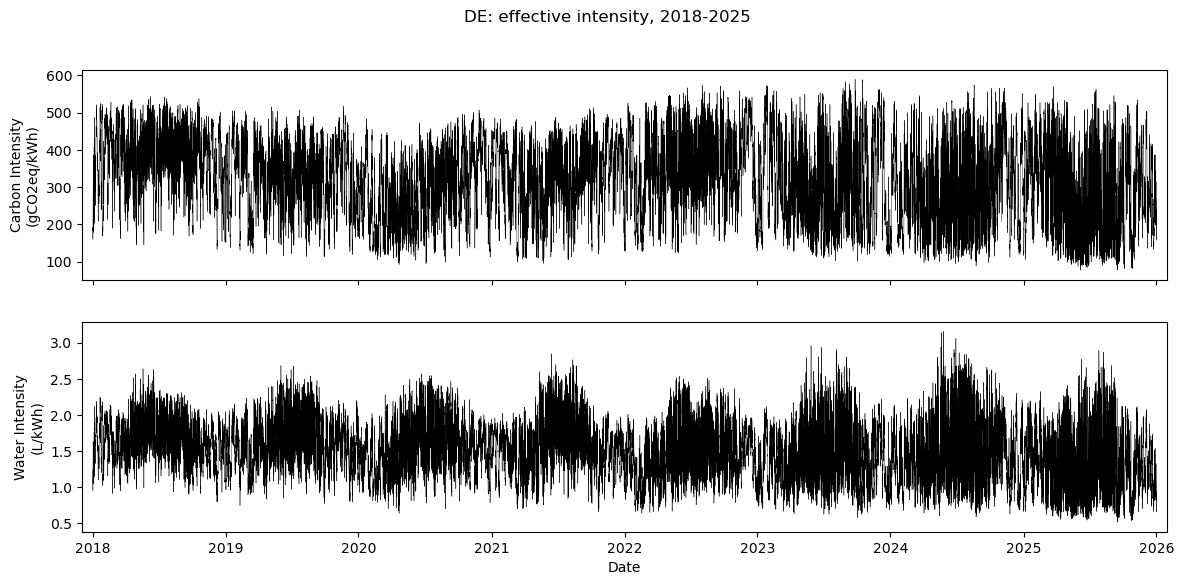

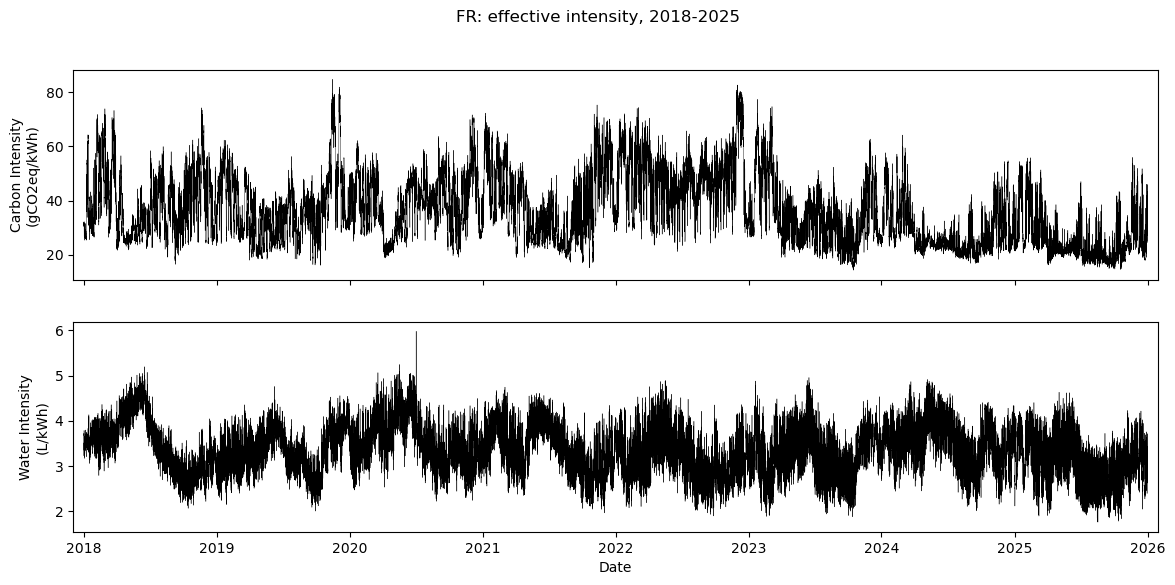

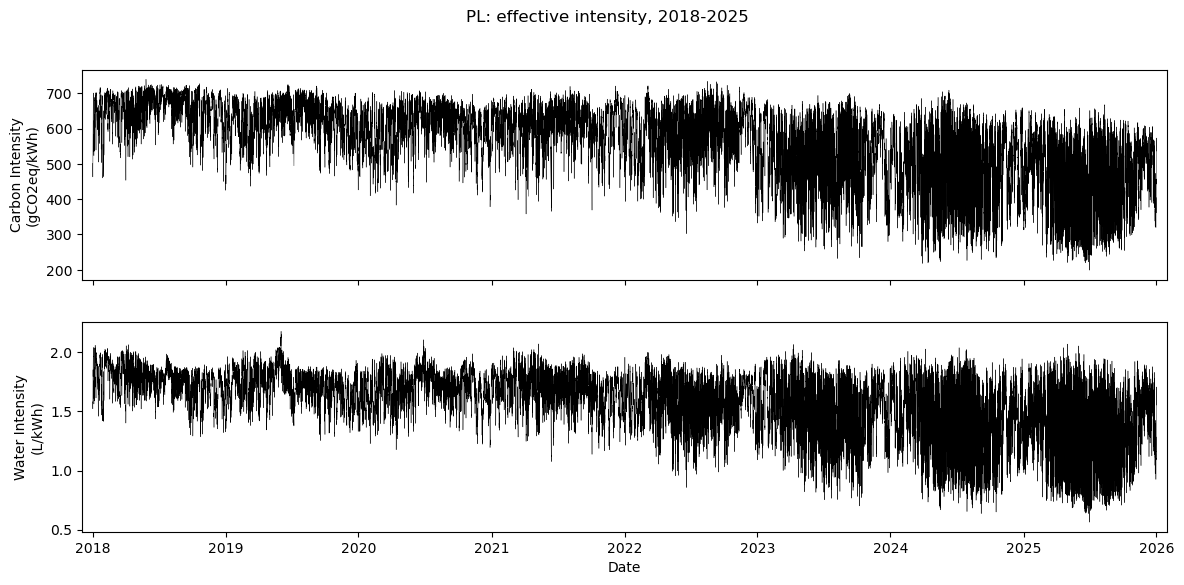

In [6]:
for cc in COUNTRIES:
    eff = intensity[cc]
    fig, (ax_c, ax_w) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    ax_c.plot(eff.index, eff["carbon"], color="black", linewidth=0.3)
    ax_c.set_ylabel("Carbon Intensity\n(gCO2eq/kWh)")
    ax_w.plot(eff.index, eff["water"], color="black", linewidth=0.3)
    ax_w.set_ylabel("Water Intensity\n(L/kWh)")
    ax_w.set_xlabel("Date")
    for ax in (ax_c, ax_w):
        ax.margins(x=0.01)
    fig.suptitle(f"{cc}: effective intensity, 2018-2025")
    plt.show()

## Sample week

One fixed week zoomed in to show the diurnal pattern the time-shifting heuristics exploit: the midday solar valley in the carbon signal, and the morning/evening demand ramps served by dispatchable (hydro or fossil) generation.

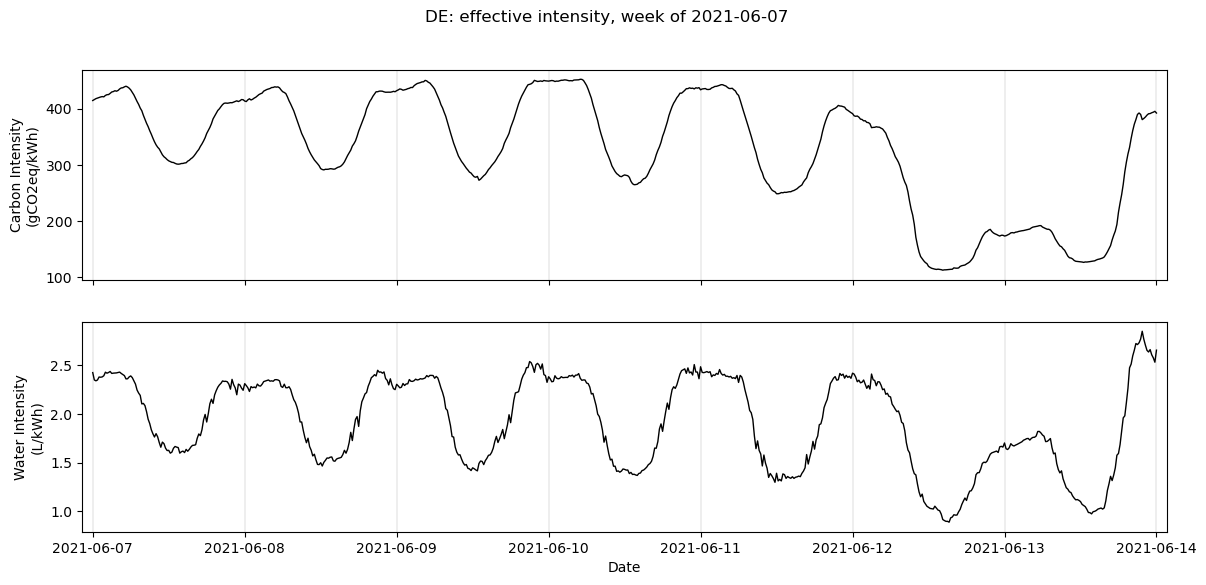

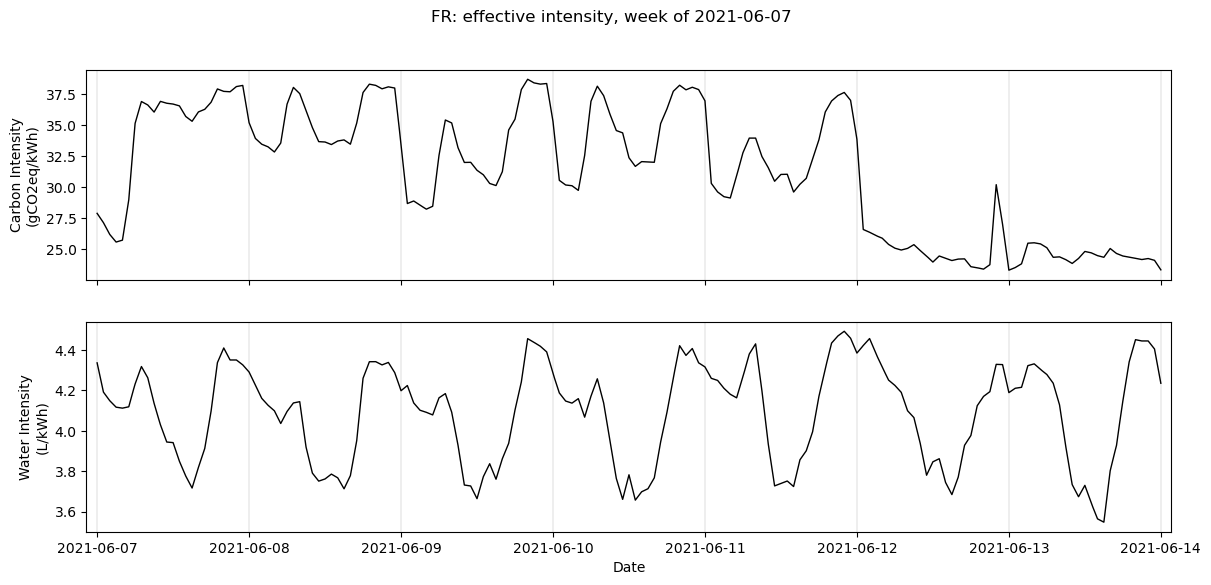

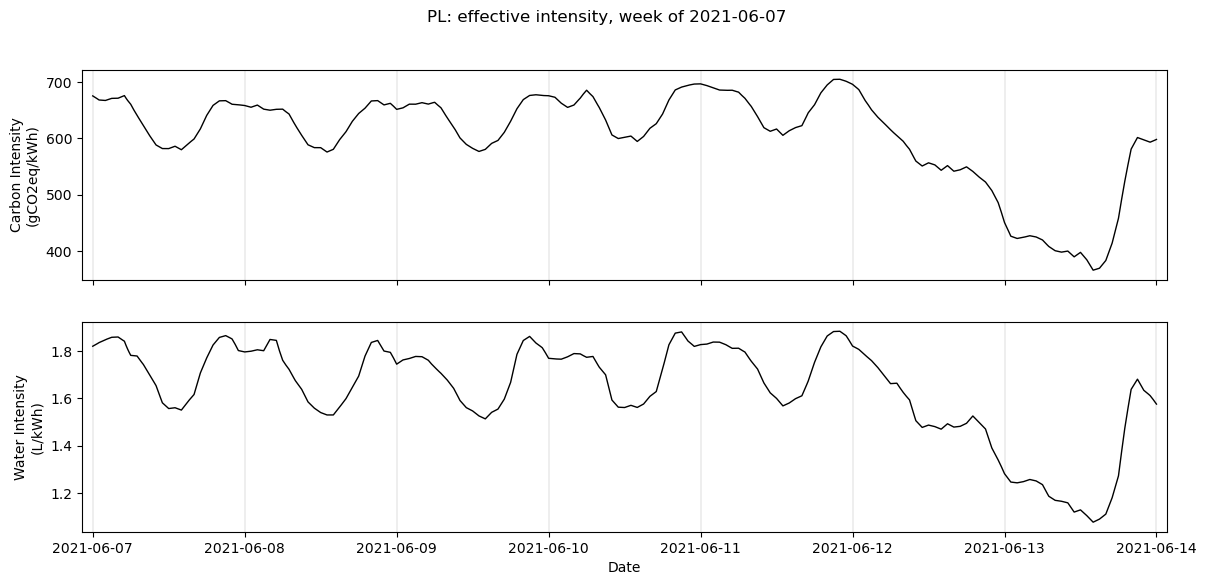

In [7]:
for cc in COUNTRIES:
    start = pd.Timestamp(SAMPLE_WEEK, tz=lookup_area(cc).tz)
    week = intensity[cc][start : start + pd.Timedelta(days=7)]
    fig, (ax_c, ax_w) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    ax_c.plot(week.index, week["carbon"], color="black", linewidth=1)
    ax_c.set_ylabel("Carbon Intensity\n(gCO2eq/kWh)")
    ax_w.plot(week.index, week["water"], color="black", linewidth=1)
    ax_w.set_ylabel("Water Intensity\n(L/kWh)")
    ax_w.set_xlabel("Date")
    for ax in (ax_c, ax_w):
        ax.margins(x=0.01)
        ax.grid(axis="x", linewidth=0.3)
    fig.suptitle(f"{cc}: effective intensity, week of {SAMPLE_WEEK}")
    plt.show()

## Generation mix

Weekly mean share of each source, to document what drives each zone's intensity: PL is coal-dominated, FR nuclear-dominated, DE the most mixed and the fastest-changing. Sources are stacked in the column order of the cleaned data.

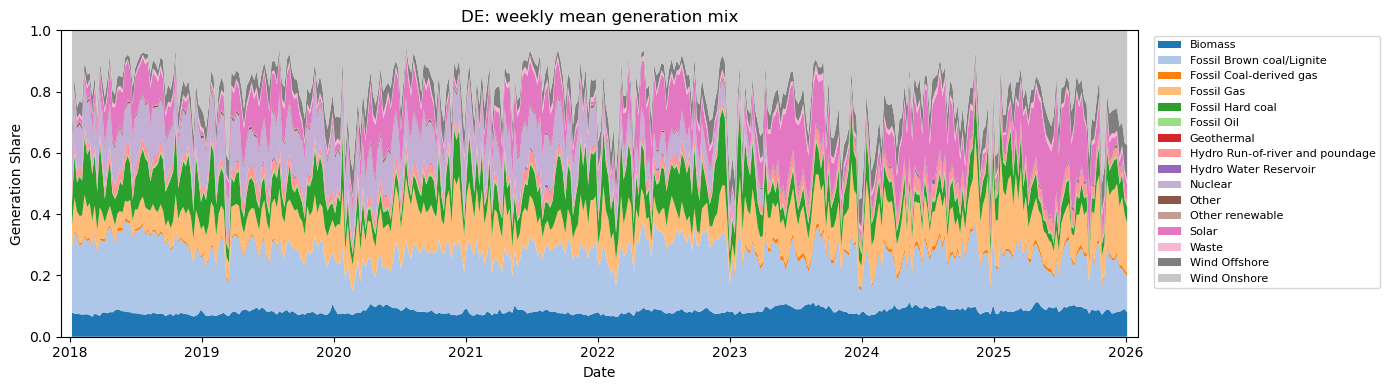

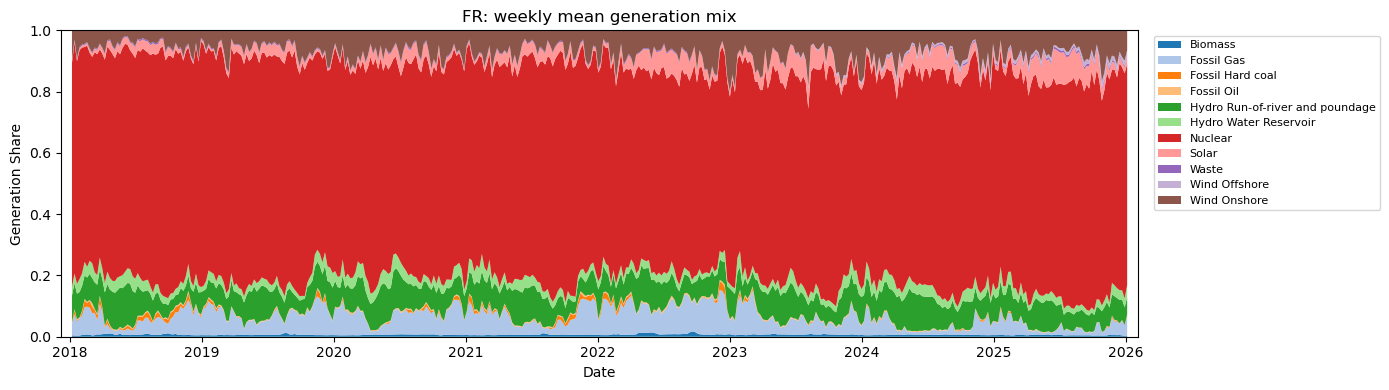

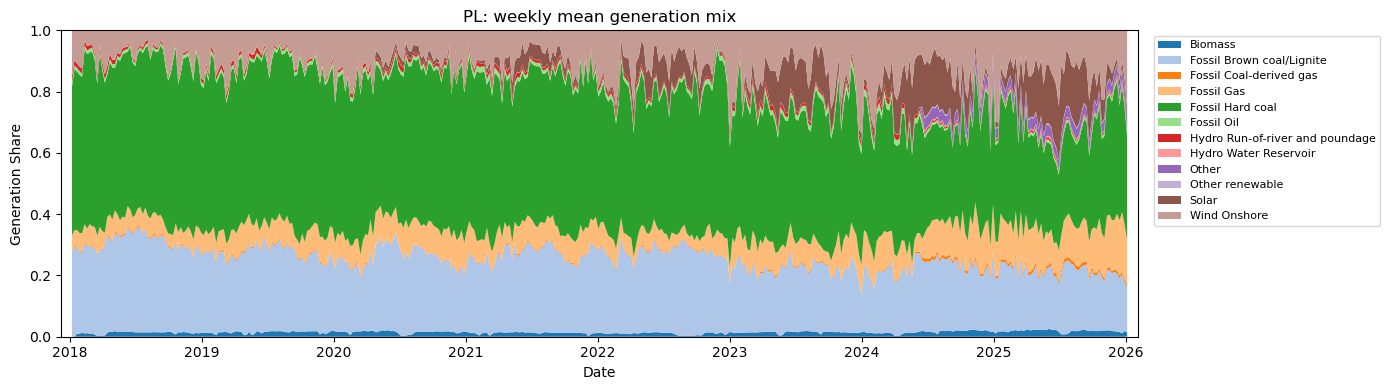

In [8]:
for cc in COUNTRIES:
    gen = cleaned[cc]
    share = gen.div(gen.sum(axis=1), axis=0).resample("W").mean()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.stackplot(share.index, share.T.to_numpy(), labels=share.columns,
                 colors=plt.cm.tab20.colors)
    ax.set_ylabel("Generation Share")
    ax.set_xlabel("Date")
    ax.set_ylim(0, 1)
    ax.margins(x=0.01)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
    ax.set_title(f"{cc}: weekly mean generation mix")
    fig.tight_layout()
    plt.show()

## Writing the traces

Long format Batsim consumes: `timestamp,zone,property,value`, two properties per instant (`carbon_intensity` in gCO2eq/kWh, `water_intensity` in L/kWh), values rounded to 4 decimals. Timestamps are seconds elapsed since the trace start (2018-01-01 00:00 local time), stepping by 900.

In [9]:
for cc in COUNTRIES:
    eff = intensity[cc]
    timestamps = ((eff.index - eff.index[0]).total_seconds()).astype(int)
    trace = pd.DataFrame({
        "timestamp": timestamps.repeat(2),
        "zone": ZONE_ID,
        "property": ["carbon_intensity", "water_intensity"] * len(eff),
        "value": [v for pair in zip(eff["carbon"].round(4), eff["water"].round(4)) for v in pair],
    })
    trace.to_csv(f"traces/{cc}.csv", index=False)
    print(f"{cc}: wrote {len(trace)} rows to traces/{cc}.csv")

DE: wrote 561024 rows to traces/DE.csv


FR: wrote 561024 rows to traces/FR.csv


PL: wrote 561024 rows to traces/PL.csv


## Validation

Re-read each trace from disk and check: 280512 instants (8 years at 15-minute resolution), timestamps 0 to 252459900 stepping 900, exactly two properties per instant, zone always `AS0`, no missing values.

In [10]:
N_INSTANTS = 280512  # 2922 days (2018-2025, two leap years) x 96 steps

for cc in COUNTRIES:
    trace = pd.read_csv(f"traces/{cc}.csv")
    assert (trace["zone"] == ZONE_ID).all(), cc
    wide = trace.pivot(index="timestamp", columns="property", values="value")
    assert len(trace) == 2 * len(wide), cc
    assert len(wide) == N_INSTANTS, cc
    assert (wide.index == np.arange(N_INSTANTS) * STEP_SEC).all(), cc
    assert list(wide.columns) == ["carbon_intensity", "water_intensity"], cc
    assert not wide.isna().any().any(), cc
    print(f"{cc}: validated {len(wide)} instants, 0 to {wide.index[-1]} stepping {STEP_SEC}, "
          f"2 properties, no missing values")

DE: validated 280512 instants, 0 to 252459900 stepping 900, 2 properties, no missing values


FR: validated 280512 instants, 0 to 252459900 stepping 900, 2 properties, no missing values


PL: validated 280512 instants, 0 to 252459900 stepping 900, 2 properties, no missing values
